<a href="https://colab.research.google.com/github/mukul-mschauhan/Data-Analytics/blob/master/Intro_to_Regex_Workathon%2013-Jan-2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem Statement

The new covid-era has provided a new way of living the work-life balance. We have seen a lot of different websites providing **packages to work from different locations.** From Kashmir to Kanyakumari, from Gujarat to Assam we have collected packages in and around India.

It becomes really difficult to find the best place with all the amenities such as **high-speed internet, a comfortable stay as well as within the budget.** To solve the real-world problem of finding the best deals for a calm and enjoying workation trip. **Workation is the best way to work at a remote location with a recreational and rejuvenating vacation for the team.**

In this competition, one has to use the knowledge of machine learning, deep learning, and model building to **predict the price per person** for your next workstation trip. The data has more than 18000+ rows of different packages with the details like start location, hotel type, cost per person, destination, Itinerary, and many more.

#### Attributes:

* Uniq Id - Unique Identifier per row sample
* Package Name - Name of the tour package
* Package Type - Type of the tour package
* Destination - A destination place
* Itinerary - complete itinerary
* Places Covered - covered places in the itinerary
* Travel Date - Date of travel
* Hotel Details - Details of the hotel stay
* Start City - Start place for the travel
* Airline - Flight details
* Flight Stops - Intermediate stops if any
* Meals - Inflight meals or services
* Sightseeing Places Covered - Itinerary details regarding sightseeing
* Cancellation Rules - Cancellation policy as per travel company
* **Per Person Price** - Price of the tour package per person (Target Column)

#### Evaluation Criteria: **RMSLE(Root Mean Squared Log Error)** as a metric to generalize well on unseen data

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("/content/Train.csv")
train.head()

,Uniq Id,Package Name,Package Type,Destination,Itinerary,Places Covered,Travel Date,Hotel Details,Start City,Airline,Flight Stops,Meals,Sightseeing Places Covered,Cancellation Rules,Per Person Price
0,e788ab76d9d8cf1e6ed2f139645ca5d1,Best of Shimla and Manali Holiday from Delhi,Standard,New Delhi|Shimla|Manali|Chandigarh,1N New Delhi . 2N Shimla . 2N Manali . 1N Chan...,New Delhi|Shimla|Manali|Chandigarh,30-07-2021,Not Available,Mumbai,Not Available,2,3,Not Available,Not Available,11509.0
1,178f892630ce3e335a5a41d5d83937fd,Kashmir Valley vacation,Premium,Srinagar|Pahalgam|Srinagar,1N Srinagar . 2N Pahalgam . 1N Srinagar,Srinagar|Pahalgam|Srinagar,08-12-2021,The Orchard Retreat & Spa:4.6|WelcomHotel Pine...,New Delhi,IndiGo|IndiGo,0,5,Dal Lake | Avantipura Ruins | Mughal Gardens ...,Cancellation any time after making the 1st pay...,22485.5
2,f060f2954840503cc2fdaf495357b7df,Might of Mewar- Udaipur and Chittorgarh,Luxury,Udaipur|Chittorgarh,2N Udaipur . 1N Chittorgarh,Udaipur|Chittorgarh,26-04-2021,The Ananta:4.4|juSTa Lake Nahargarh Palace:4,New Delhi,IndiGo,0,4,Lake Pichola | Jag Mandir Palace | Saheliyon ...,Cancellation any time after making the 1st pay...,12421.5
3,32a19a6c171e67448f2346da46c619dc,Colorful Kerala ( Romantic Getaway ),Premium,Munnar|Kumarakom|Allepey|Kovalam and Poovar,2N Munnar . 1N Kumarakom . 1N Allepey . 2N Kov...,Munnar|Kumarakom|Allepey|Kovalam and Poovar,27-08-2021,Elixir Hills Suites Resort & Spa-MMT Holidays ...,New Delhi,IndiGo,0,5,Mattupetty Dam | Echo Point | Tata Tea Museum...,Cancellation any time after making the 1st pay...,35967.0
4,107b068aa0ca03bc6248966f594d105f,A Week In Bangkok & Pattaya,Premium,Pattaya|Bangkok,4N Pattaya . 3N Bangkok,Pattaya|Bangkok,12-12-2021,Dusit Thani Pattaya - MMT Special:4.5|Amari Wa...,New Delhi,Spicejet|Go Air,0,5,"Coral Island Tour with Indian Lunch, Join Spe...",Cancellation any time after making the 1st pay...,25584.0


In [4]:
train['Uniq Id'].shape # ID is equal to the number of rows in the data
# Most Likely they are not repeated and hence of no use to us.

# If the ID let say are only 100 then it has lot of information
# and can be used to extract new features....

(21000,)

In [6]:
# Drop the ID
train.drop("Uniq Id", axis = 1, inplace = True)

In [7]:
train.head()

,Package Name,Package Type,Destination,Itinerary,Places Covered,Travel Date,Hotel Details,Start City,Airline,Flight Stops,Meals,Sightseeing Places Covered,Cancellation Rules,Per Person Price
0,Best of Shimla and Manali Holiday from Delhi,Standard,New Delhi|Shimla|Manali|Chandigarh,1N New Delhi . 2N Shimla . 2N Manali . 1N Chan...,New Delhi|Shimla|Manali|Chandigarh,30-07-2021,Not Available,Mumbai,Not Available,2,3,Not Available,Not Available,11509.0
1,Kashmir Valley vacation,Premium,Srinagar|Pahalgam|Srinagar,1N Srinagar . 2N Pahalgam . 1N Srinagar,Srinagar|Pahalgam|Srinagar,08-12-2021,The Orchard Retreat & Spa:4.6|WelcomHotel Pine...,New Delhi,IndiGo|IndiGo,0,5,Dal Lake | Avantipura Ruins | Mughal Gardens ...,Cancellation any time after making the 1st pay...,22485.5
2,Might of Mewar- Udaipur and Chittorgarh,Luxury,Udaipur|Chittorgarh,2N Udaipur . 1N Chittorgarh,Udaipur|Chittorgarh,26-04-2021,The Ananta:4.4|juSTa Lake Nahargarh Palace:4,New Delhi,IndiGo,0,4,Lake Pichola | Jag Mandir Palace | Saheliyon ...,Cancellation any time after making the 1st pay...,12421.5
3,Colorful Kerala ( Romantic Getaway ),Premium,Munnar|Kumarakom|Allepey|Kovalam and Poovar,2N Munnar . 1N Kumarakom . 1N Allepey . 2N Kov...,Munnar|Kumarakom|Allepey|Kovalam and Poovar,27-08-2021,Elixir Hills Suites Resort & Spa-MMT Holidays ...,New Delhi,IndiGo,0,5,Mattupetty Dam | Echo Point | Tata Tea Museum...,Cancellation any time after making the 1st pay...,35967.0
4,A Week In Bangkok & Pattaya,Premium,Pattaya|Bangkok,4N Pattaya . 3N Bangkok,Pattaya|Bangkok,12-12-2021,Dusit Thani Pattaya - MMT Special:4.5|Amari Wa...,New Delhi,Spicejet|Go Air,0,5,"Coral Island Tour with Indian Lunch, Join Spe...",Cancellation any time after making the 1st pay...,25584.0


### EDA Process

* Univariate Analysis
* Bivariate Analysis
* Missing Values Identification & Treatment
* Outliers Identification & Removal
* **Feature Engineering**
* Scaling & Transformation

* Scaling - Linear & Logistic Regression. No need to scale the data in Tree Based Models.

Note: Neural Net needs Scaling and so is the case of Clustering/KNN.

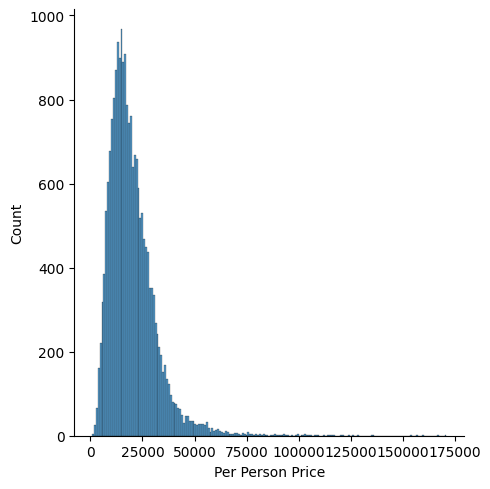

In [8]:
# Target Variable - Price per person...
# It will be highly skewed...

sns.displot(train['Per Person Price'])
plt.show()

In [17]:
len(train.Destination[0].split("|")) # Count of the Destination

4

In [19]:
train["Count_Destination"] = train.Destination.apply(lambda x:len(x.split("|")))
train["Count_SS"] = train["Sightseeing Places Covered"].apply(lambda x:len(x.split("|")))

In [23]:
# Airline
train["Count_Airline"] = train.Airline.apply(lambda x:len(x.split("|")))

In [24]:
# Lets check the Correlation
train.loc[:, ["Count_Destination", "Count_SS",
              "Count_Airline", "Per Person Price"]].corr()

,Count_Destination,Count_SS,Count_Airline,Per Person Price
Count_Destination,1.000000,0.432198,0.077882,0.317759
Count_SS,0.432198,1.000000,-0.169605,0.140275
Count_Airline,0.077882,-0.169605,1.000000,0.432892
Per Person Price,0.317759,0.140275,0.432892,1.000000


In [33]:
train.Itinerary[3].split(".")

# regex..regular expression...

['2N Munnar ', ' 1N Kumarakom ', ' 1N Allepey ', ' 2N Kovalam and Poovar']

In [36]:
# Extracting the Number of the Days from Itinerary

import re

def extract(text):
  num_days = re.findall('\d', text)
  days = pd.to_numeric(num_days)
  return(np.sum(days))

train["Holiday_Duration"] = train.Itinerary.apply(extract)

In [39]:
train['Hotel Details'].unique()

array(['Not Available',
       'The Orchard Retreat & Spa:4.6|WelcomHotel Pine N Peak Pahalgam - Member ITC Hotel Group:4.1|The Orchard Retreat & Spa:4.6',
       'The Ananta:4.4|juSTa Lake Nahargarh Palace:4', ...,
       'Hotel The Royal Plaza:4.0|The Taj Vilas:4.0|Lemon Tree Premier Jaipur:4.5',
       'Club Mahindra Virajpet, Coorg:4|The Quorum:3.5|Hotel Meadows Residency:4.4',
       'Poppys Hotel:Four|Hyatt Place Rameswaram:Four|Vinayaga by Poppys:Three|Svatma:Four|Red Fox Hotel ,Trichy:Three|Kodai Resort Hotel:Four'],
      dtype=object)

In [40]:
mytext = 'Poppys Hotel:Four|Hyatt Place Rameswaram:Four|Vinayaga by Poppys:Three|Svatma:Four|Red Fox Hotel ,Trichy:Three|Kodai Resort Hotel:Four'
print(mytext)

Poppys Hotel:Four|Hyatt Place Rameswaram:Four|Vinayaga by Poppys:Three|Svatma:Four|Red Fox Hotel ,Trichy:Three|Kodai Resort Hotel:Four


In [51]:
def manipulate_rating(text):
  text = text.replace(":One", ":1.0")
  text = text.replace(":Two", ":2.0")
  text = text.replace(":Three", ":3.0")
  text = text.replace(":Four", ":4.0")
  text = text.replace(":Five", ":5.0")
  return text

manipulate_rating(mytext)

'Poppys Hotel:4.0|Hyatt Place Rameswaram:4.0|Vinayaga by Poppys:3.0|Svatma:4.0|Red Fox Hotel ,Trichy:3.0|Kodai Resort Hotel:4.0'

In [107]:
train["Hotel"] = train["Hotel Details"].apply(manipulate_rating)

In [108]:
train.Hotel.unique()

array(['Not Available',
       'The Orchard Retreat & Spa:4.6|WelcomHotel Pine N Peak Pahalgam - Member ITC Hotel Group:4.1|The Orchard Retreat & Spa:4.6',
       'The Ananta:4.4|juSTa Lake Nahargarh Palace:4', ...,
       'Hotel The Royal Plaza:4.0|The Taj Vilas:4.0|Lemon Tree Premier Jaipur:4.5',
       'Club Mahindra Virajpet, Coorg:4|The Quorum:3.5|Hotel Meadows Residency:4.4',
       'Poppys Hotel:4.0|Hyatt Place Rameswaram:4.0|Vinayaga by Poppys:3.0|Svatma:4.0|Red Fox Hotel ,Trichy:3.0|Kodai Resort Hotel:4.0'],
      dtype=object)

In [109]:
def ratings(text):
  if text == "Not Available":
    return(0)
  else:
    preprocessed = re.findall("[\d]+(?:\.[\d]+)", text)
    numeric = pd.to_numeric(preprocessed)
    return np.mean(numeric)

train["Rating"] = train.Hotel.apply(ratings)

train.Rating.describe()

,Rating
count,19497.000000
mean,3.481031
std,1.512554
min,0.000000
25%,3.700000
50%,4.000000
75%,4.300000
max,5.000000


In [110]:
train.Rating.isnull().sum()

1503

In [59]:
#train.loc[train.Rating.isnull(), "Hotel Details"].unique()

# UDAY SAMUDRA LEISURE BEACH HOTEL & SPA-MMT Holidays Special:4|Hotel Sivamurugan:
# Palmtree Leaf-MMT Holidays Special:', 'Hotel Vintage:4
# Casino Hotel - Cgh Earth-MMT Holidays Special:|Parakkat Nature Resorts:|The Mountain Courtyard-MMT Holidays Special:|Marari Beach - CGH Earth:
# Omega Residency:4|Summit Namnang Courtyard & Spa, Gangtok-MMT Holidays Special:5|OYO 28229 Samfelma Lodge:

In [111]:
first_text = "UDAY SAMUDRA LEISURE BEACH HOTEL & SPA-MMT Holidays Special:|Hotel Sivamurugan:"

def missed(text):
  if re.findall('[\d]+(?:\.[\d]+)',text) is None:
    return (0)
  else:
    pre = re.findall(r':(\d+)', text)
    num = pd.to_numeric(pre)
    return np.mean(num)

In [112]:
hotels = train.loc[train.Rating.isnull(), "Hotel"]
for i in hotels:
  train.loc[train.Rating.isnull(), "Rating"] = missed(i)

In [119]:
# Drop the Features

new = train.drop(["Itinerary", "Destination",
            "Places Covered", "Hotel Details", "Airline", "Hotel", "Sightseeing Places Covered"], axis = 1)



,Package Name,Package Type,Travel Date,Start City,Flight Stops,Meals,Cancellation Rules,Per Person Price,Count_Destination,Count_SS,Count_Airline,Holiday_Duration,Rating
0,Best of Shimla and Manali Holiday from Delhi,Standard,30-07-2021,Mumbai,2,3,Not Available,11509.0,4,1,1,6,0.000000
1,Kashmir Valley vacation,Premium,08-12-2021,New Delhi,0,5,Cancellation any time after making the 1st pay...,22485.5,3,7,2,4,4.433333
2,Might of Mewar- Udaipur and Chittorgarh,Luxury,26-04-2021,New Delhi,0,4,Cancellation any time after making the 1st pay...,12421.5,2,8,1,3,4.400000
3,Colorful Kerala ( Romantic Getaway ),Premium,27-08-2021,New Delhi,0,5,Cancellation any time after making the 1st pay...,35967.0,4,9,1,6,4.500000
4,A Week In Bangkok & Pattaya,Premium,12-12-2021,New Delhi,0,5,Cancellation any time after making the 1st pay...,25584.0,2,2,2,7,4.350000


In [121]:
mapped = {"Mumbai": 0, "New Delhi": 1}

new["Start City"] = new["Start City"].map(mapped)

In [123]:
# Package Type
new["Package Type"].unique()

array(['Standard', 'Premium', 'Luxury', 'Deluxe', 'Budget'], dtype=object)

In [124]:
new.groupby("Package Type")["Per Person Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Package Type,,,,,,,,
Budget,466.0,14151.447425,8236.467588,1757.0,8901.250,13114.25,17927.00,64008.5
Deluxe,6006.0,18409.508825,10228.326587,1198.0,12119.000,16426.75,22774.25,171062.5
Luxury,3278.0,23679.556437,11958.923869,2963.0,15471.625,22222.50,29170.75,107850.0
Premium,5581.0,23965.407006,13272.618593,2967.0,15232.000,21767.50,29188.00,170763.0
Standard,5669.0,16354.089081,9363.498521,791.0,10563.500,14729.50,19972.00,153795.0


In [125]:
mapped = {"Budget":0, "Standard":1, "Deluxe":2, "Luxury":3, "Premium":4}

new["Package Type"] = new["Package Type"].map(mapped)

### Create Magical Features Using Package Type, Name and Holidauyd

* Give me the Average Spend across all the Package Type, Min and Max Std
* Give me the Average Spend across all the Holidays, Min, Mean median, Max Std
* Give me the Average Spend across all the Package Names, Min, Mean median, Max Std

In [133]:
new.groupby("Package Type")["Per Person Price"].describe()

new["Magic1"]=new.groupby("Package Type")["Per Person Price"].transform("count")
new["Magic2"]=new.groupby("Package Type")["Per Person Price"].transform("min")
new["Magic3"]=new.groupby("Package Type")["Per Person Price"].transform("max")
new["Magic4"]=new.groupby("Package Type")["Per Person Price"].transform("mean")
new["Magic5"]=new.groupby("Package Type")["Per Person Price"].transform("median")
new["Magic6"]=new.groupby("Package Type")["Per Person Price"].transform("std")

In [134]:
new.groupby("Package Name")["Per Person Price"].describe()[0:5]

,count,mean,std,min,25%,50%,75%,max
Package Name,,,,,,,,
02 Night Singapore and 02 Night Genting Dream Cruise,1.0,41235.500000,NaN,41235.5,41235.50,41235.5,41235.50,41235.5
2 Nights Dubai and 2 Nights Sharjah Holiday,11.0,33619.000000,15985.878498,22953.5,27087.00,27561.0,30032.75,78037.5
2 Nights Moscow & 2 Nights Saint Petersburg,3.0,24591.666667,1014.425494,23445.5,24200.50,24955.5,25164.75,25374.0
2 Nights each in Jodhpur & Jaisalmer,9.0,19187.222222,2873.669345,13791.0,18052.50,19408.5,20529.50,24163.5
2 Nights in Munnar with Thekkady and Cochin,11.0,11667.181818,2308.866673,8771.0,9539.75,12240.5,13562.00,15073.0


In [135]:
new["Magic7"]=new.groupby("Package Name")["Per Person Price"].transform("count")
new["Magic8"]=new.groupby("Package Name")["Per Person Price"].transform("min")
new["Magic9"]=new.groupby("Package Name")["Per Person Price"].transform("max")
new["Magic10"]=new.groupby("Package Name")["Per Person Price"].transform("mean")
new["Magic11"]=new.groupby("Package Name")["Per Person Price"].transform("median")

In [138]:
new.groupby("Holiday_Duration")["Per Person Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Holiday_Duration,,,,,,,,
1,57.0,4829.833333,2889.229232,2000.0,2868.000,3550.00,6841.500,12009.5
2,1758.0,9495.006826,4959.143036,791.0,6099.625,8740.50,11452.625,48887.0
3,4162.0,13997.181764,7491.420379,2241.0,9415.750,12491.50,16921.000,170763.0
4,4092.0,18374.637463,8730.728324,3667.0,12583.375,16634.50,22471.125,79400.0
5,4211.0,22046.096889,10514.990563,4917.0,15183.500,19949.00,26055.500,124621.0
6,3507.0,24269.536213,10404.136747,5823.5,16765.250,22316.00,29113.500,91155.0
7,1908.0,26645.223532,11138.002296,10390.5,18211.750,25245.50,32102.250,93325.0
8,719.0,28825.093185,15695.028448,10424.5,19446.500,25633.00,33058.500,159740.0
9,311.0,35215.173633,16996.165853,15780.5,24473.500,32723.50,39817.000,166758.0


In [141]:
new["Magic12"]=new.groupby("Holiday_Duration")["Per Person Price"].transform("count")
new["Magic13"]=new.groupby("Holiday_Duration")["Per Person Price"].transform("min")
new["Magic14"]=new.groupby("Holiday_Duration")["Per Person Price"].transform("max")
new["Magic15"]=new.groupby("Holiday_Duration")["Per Person Price"].transform("mean")
new["Magic16"]=new.groupby("Holiday_Duration")["Per Person Price"].transform("median")
new["Magic17"]=new.groupby("Holiday_Duration")["Per Person Price"].transform("std")

In [142]:
pd.set_option('display.max_columns', 100)
new.head()

,Package Name,Package Type,Travel Date,Start City,Flight Stops,Meals,Cancellation Rules,Per Person Price,Count_Destination,Count_SS,Count_Airline,Holiday_Duration,Rating,Magic1,Magic2,Magic3,Magic4,Magic5,Magic6,Magic7,Magic8,Magic9,Magic10,Magic11,Magic12,Magic13,Magic14,Magic15,Magic16,Magic17
0,Best of Shimla and Manali Holiday from Delhi,1,30-07-2021,0,2,3,Not Available,11509.0,4,1,1,6,0.000000,5669,791.0,153795.0,16354.089081,14729.5,9363.498521,17,10882.0,30095.5,15746.735294,13478.0,3507,5823.5,91155.0,24269.536213,22316.0,10404.136747
1,Kashmir Valley vacation,4,08-12-2021,1,0,5,Cancellation any time after making the 1st pay...,22485.5,3,7,2,4,4.433333,5581,2967.0,170763.0,23965.407006,21767.5,13272.618593,9,13231.5,22485.5,17496.555556,16730.5,4092,3667.0,79400.0,18374.637463,16634.5,8730.728324
2,Might of Mewar- Udaipur and Chittorgarh,3,26-04-2021,1,0,4,Cancellation any time after making the 1st pay...,12421.5,2,8,1,3,4.400000,3278,2963.0,107850.0,23679.556437,22222.5,11958.923869,14,10460.5,15218.5,12576.178571,12407.0,4162,2241.0,170763.0,13997.181764,12491.5,7491.420379
3,Colorful Kerala ( Romantic Getaway ),4,27-08-2021,1,0,5,Cancellation any time after making the 1st pay...,35967.0,4,9,1,6,4.500000,5581,2967.0,170763.0,23965.407006,21767.5,13272.618593,15,13458.0,35967.0,20569.500000,19149.0,3507,5823.5,91155.0,24269.536213,22316.0,10404.136747
4,A Week In Bangkok & Pattaya,4,12-12-2021,1,0,5,Cancellation any time after making the 1st pay...,25584.0,2,2,2,7,4.350000,5581,2967.0,170763.0,23965.407006,21767.5,13272.618593,13,15850.0,31615.5,21775.807692,18595.0,1908,10390.5,93325.0,26645.223532,25245.5,11138.002296


In [143]:
new.drop("Package Name", axis = 1, inplace = True)

In [146]:
# Convert the travel date
new["Travel Date"] = pd.to_datetime(new["Travel Date"])

In [147]:
new["Date"] = new["Travel Date"].dt.day # Date
new["Month"] = new["Travel Date"].dt.month # Date
new["Year"] = new["Travel Date"].dt.year # Date

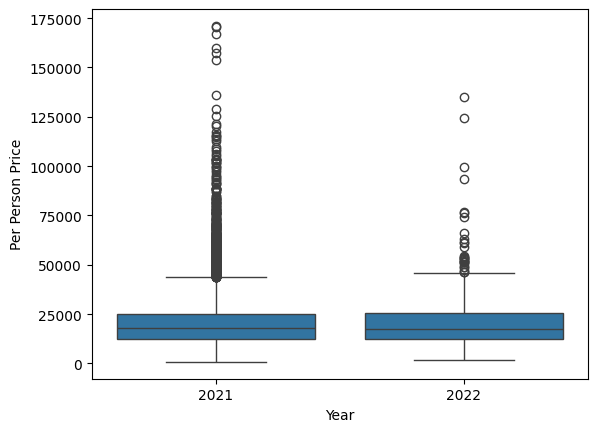

In [148]:
sns.boxplot(x = "Year", y = "Per Person Price",data = new)
plt.show()


In [150]:
# Ho: Date, month and Year are Independent of the Target. It means that there is no pattern between them
# Ha: Ho is False

import statsmodels.formula.api as sfa
from statsmodels.stats.anova import anova_lm

new["target"] = new["Per Person Price"]
model = sfa.ols("target~Date+Month+Year", data = new).fit()

print(anova_lm(model))

               df        sum_sq       mean_sq         F    PR(>F)
Date          1.0  7.926039e+06  7.926039e+06  0.058457  0.808953
Month         1.0  5.591506e+07  5.591506e+07  0.412393  0.520764
Year          1.0  8.058435e+07  8.058435e+07  0.594337  0.440755
Residual  20996.0  2.846782e+12  1.355869e+08       NaN       NaN


Inference: Since the Pvalue > Alpha, we Fail to Reject the Ho Meaning date has no relevance for the Model

In [152]:
#new.drop(["Travel Date", "Date", "Month", "Year", "target"], axis = 1, inplace = True)
new.drop("target", axis =1, inplace = True)

In [154]:
dummydata = pd.get_dummies(new, drop_first = True)

X = dummydata.drop("Per Person Price", axis = 1)
y = dummydata["Per Person Price"]

In [156]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_log_error

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size = 0.30,
                                                random_state = 42)

dtree = DecisionTreeRegressor()
rf = RandomForestRegressor()
gbm = GradientBoostingRegressor()
xgb = XGBRegressor()
lg = LGBMRegressor()

pred_tree = dtree.fit(xtrain, ytrain).predict(xtest)
cost = np.sqrt(mean_squared_log_error(ytest, pred_tree))
print("Decision Tree", cost)

pred_rf = rf.fit(xtrain, ytrain).predict(xtest)
cost = np.sqrt(mean_squared_log_error(ytest, pred_rf))
print("RandomForest", cost)

Decision Tree 0.22134390116777838
RandomForest 0.18473317763061217


In [158]:
pred_gbm = gbm.fit(xtrain, ytrain).predict(xtest)
cost = np.sqrt(mean_squared_log_error(ytest, pred_gbm))
print("Gradient Boosting", cost)

pred_xgb = xgb.fit(xtrain, ytrain).predict(xtest)
cost = np.sqrt(mean_squared_log_error(ytest, pred_xgb))
print("XGBoost", cost)

Gradient Boosting 0.20079202514140154
XGBoost 0.18413692702631937


In [160]:
xtrain, xtest, ytrain, ytest = train_test_split(X, np.log(y), test_size = 0.30,
                                                random_state = 42)

dtree = DecisionTreeRegressor()
rf = RandomForestRegressor()
gbm = GradientBoostingRegressor()
xgb = XGBRegressor()
lg = LGBMRegressor()

pred_tree = dtree.fit(xtrain, ytrain).predict(xtest)
cost = np.sqrt(mean_squared_log_error(ytest, np.exp(pred_tree)))
print("Decision Tree", cost)

pred_rf = rf.fit(xtrain, ytrain).predict(xtest)
cost = np.sqrt(mean_squared_log_error(ytest, np.exp(pred_rf)))
print("RandomForest", cost)

Decision Tree 7.430236063107912
RandomForest 7.424136775487729
